# LLM-Based Text Watermark Detection using Llama 3.2 + NLP

**LLM:** Ollama `llama3.2`  
**NLP:** TF-IDF, n-grams, stylometric features  
**Classifier:** Logistic Regression  
**Metrics:** Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix  
**Interface:** Jupyter Notebook — no Streamlit, no Hugging Face.

> The supplied JSONL contains `id` and `text`, but no watermark labels. This notebook therefore creates an experimental synthetic detection dataset from Llama 3.2 outputs. The resulting scores are for this experimental setup.


## 1. Install dependencies

In [ ]:
!pip install -q ollama pandas numpy scipy scikit-learn nltk matplotlib seaborn tqdm joblib


## 2. Imports

In [1]:
import json
import re
import math
import hashlib
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ollama

from tqdm.auto import tqdm
from scipy.sparse import csr_matrix, hstack

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


## 3. Configure Ollama + Llama 3.2

Run `ollama pull llama3.2` in your terminal first.

In [2]:
LLM_MODEL = "llama3.2"
print("Using LLM:", LLM_MODEL)


Using LLM: llama3.2


## 4. Load the JSONL dataset

In [3]:
DATA_PATH = r"C:\Users\T14s\Downloads\train.jsonl"

records = []

with open(DATA_PATH, "r", encoding="utf-8") as file:
    for line in file:
        if line.strip():
            records.append(json.loads(line))

df = pd.DataFrame(records)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())


Shape: (300, 2)
Columns: ['id', 'text']


,id,text
0,9a28d103-7b2e-43da-b511-2efb5f91975f,"Mr President, the digital services act (DSA) i..."
1,4fcae8a8-f5e6-4ccd-9dae-10b609a47cfc,"Mr President, dear Commissioner, dear colleagu..."
2,91a6fd5b-dd14-4725-83ef-0ef6309f9b0e,"Mr President, I would like to make two points ..."
3,638cf8b7-51ca-4625-97c0-21ce92140c9a,"Madam President, Madam High Representative, th..."
4,8f9857c7-e933-488e-a6de-94ffbdb685a8,"Mr President, the Council decision not to open..."


## 5. Text preprocessing

In [4]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df = df.dropna(subset=["text"]).copy()
df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

print("Usable records:", len(df))


Usable records: 300


## 6. Basic statistics

In [5]:
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))
df["char_count"] = df["clean_text"].apply(len)

display(df[["word_count", "char_count"]].describe())


,word_count,char_count
count,300.000000,300.000000
mean,386.610000,2338.646667
std,176.575653,1090.899265
min,100.000000,567.000000
25%,212.750000,1309.750000
50%,368.000000,2211.000000
75%,551.500000,3308.500000
max,695.000000,4491.000000


## 7. Llama 3.2 generation function

In [6]:
def generate_llama_text(prompt, max_tokens=120):
    response = ollama.chat(
        model=LLM_MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        options={
            "temperature": 0.7,
            "top_p": 0.9,
            "num_predict": max_tokens
        }
    )
    return response["message"]["content"]


## 8. Test Llama 3.2

In [7]:
prompt = df.iloc[0]["clean_text"][:500]

generated_text = generate_llama_text(
    prompt,
    max_tokens=120
)

print(generated_text)


...without compromising the values of free speech, fairness, and accountability that are at the heart of a healthy democracy. The Digital Services Act is a game-changer because it acknowledges that the internet is a public good, not just a private asset, and that the rules of the game should be set by the democratically elected representatives of the people, not just by the whims of private companies.

By recognizing the importance of democratic values and the need to regulate big tech, we are sending a clear message that we will no longer tolerate the undue influence of private interests over the democratic process. This legislation is a


## 9. Deterministic lexical watermark signal

Ollama's standard chat interface does not expose Llama token logits. This notebook therefore uses a deterministic lexical watermark signal. A secret key assigns words to a green list, and the detector measures the resulting statistical signal.


In [8]:
WATERMARK_KEY = "LLAMA32_NLP_WATERMARK_2026"
GREEN_FRACTION = 0.5

def is_green_word(word, key=WATERMARK_KEY):
    word = word.lower().strip()

    if not word.isalpha():
        return False

    digest = hashlib.sha256(
        f"{key}:{word}".encode("utf-8")
    ).hexdigest()

    number = int(digest, 16)

    return (number % 1_000_000) / 1_000_000 < GREEN_FRACTION


## 10. Watermark z-score detector

In [9]:
def calculate_watermark_score(text, key=WATERMARK_KEY):
    words = re.findall(r"[A-Za-z]+", text.lower())

    if len(words) < 5:
        return {
            "z_score": 0.0,
            "green_count": 0,
            "total_words": len(words),
            "green_ratio": 0.0
        }

    green_count = sum(
        is_green_word(word, key)
        for word in words
    )

    n = len(words)
    ratio = green_count / n
    expected = n * GREEN_FRACTION
    variance = n * GREEN_FRACTION * (1 - GREEN_FRACTION)

    z_score = (green_count - expected) / math.sqrt(variance)

    return {
        "z_score": z_score,
        "green_count": green_count,
        "total_words": n,
        "green_ratio": ratio
    }


## 11. Test watermark score

In [10]:
calculate_watermark_score(generated_text)


{'z_score': 1.1547005383792515,
 'green_count': 60,
 'total_words': 108,
 'green_ratio': 0.5555555555555556}

## 12. Create experimental labeled data

`0` = normal Llama 3.2 generation  
`1` = Llama 3.2 generation prompted to favor the secret watermark vocabulary signal.

These are synthetic experimental labels because the source JSONL does not contain watermark labels.


In [11]:
SAMPLE_SIZE =min(50, len(df))
generated_records = []

for i in tqdm(range(SAMPLE_SIZE)):
    source = df.iloc[i]["clean_text"][:500]
    
    normal_text = generate_llama_text(
        f"Write a natural response based on this text:\n{source}",
        max_tokens=20 # Reduced from 60
    )
    generated_records.append({
        "source_id": df.iloc[i]["id"],
        "text": normal_text,
        "label": 0,
        "generation_type": "normal"
    })
    
    watermark_prompt = f"""
    Write a natural response based on the text below.
    Use vocabulary choices that favor words associated with this secret watermark key: {WATERMARK_KEY}
    Do not mention the key or watermark. Keep the response coherent and natural.
    
    Source: {source}
    """
    watermarked_text = generate_llama_text(watermark_prompt, max_tokens=30) # Reduced from 120
    generated_records.append({
        "source_id": df.iloc[i]["id"],
        "text": watermarked_text,
        "label": 1,
        "generation_type": "watermarked"
    })

detection_df = pd.DataFrame(generated_records)
print("Detection dataset:", detection_df.shape)
print(detection_df["label"].value_counts())

  0%|          | 0/50 [00:00<?, ?it/s]

Detection dataset: (100, 4)
label
0    50
1    50
Name: count, dtype: int64


## 13. Extract watermark features

In [12]:
def extract_watermark_features(text):
    result = calculate_watermark_score(text)

    return [
        result["z_score"],
        result["green_ratio"],
        result["total_words"]
    ]

watermark_features = np.array([
    extract_watermark_features(text)
    for text in detection_df["text"]
])

print("Shape:", watermark_features.shape)


Shape: (100, 3)


## 14. Extract stylometric NLP features

In [13]:
def stylometric_features(text):
    words = re.findall(r"[A-Za-z]+", text)

    if not words:
        return [0, 0, 0, 0, 0, 0]

    sentences = [
        s.strip()
        for s in re.split(r"[.!?]+", text)
        if s.strip()
    ]

    word_lengths = [len(w) for w in words]

    unique_ratio = (
        len(set(w.lower() for w in words)) / len(words)
    )

    avg_word_length = np.mean(word_lengths)

    avg_sentence_length = (
        len(words) / max(len(sentences), 1)
    )

    punctuation_count = len(
        re.findall(r"[,;:!?]", text)
    )

    uppercase_count = len(
        re.findall(r"\b[A-Z][a-z]+\b", text)
    )

    return [
        len(words),
        avg_word_length,
        unique_ratio,
        avg_sentence_length,
        punctuation_count,
        uppercase_count
    ]

style_features = np.array([
    stylometric_features(text)
    for text in detection_df["text"]
])

print("Shape:", style_features.shape)


Shape: (100, 6)


## 15. TF-IDF features

In [14]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True
)

X_tfidf = tfidf_vectorizer.fit_transform(
    detection_df["text"]
)

print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (100, 1948)


## 15B. Sentence embeddings (Sentence-Transformers)

TF-IDF captures word/n-gram overlap but misses semantic and stylistic patterns. This section adds dense sentence embeddings from a small SBERT-style model (`all-MiniLM-L6-v2`) as an additional feature block. These are fixed-size (384-dim) vectors that fuse naturally with the watermark z-score and stylometric features already computed.

Requires internet access the first time it runs (downloads the model, ~90MB).

In [15]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

sentence_embeddings = embedding_model.encode(
    detection_df["text"].tolist(),
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Sentence embedding shape:", sentence_embeddings.shape)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Sentence embedding shape: (100, 384)


## 16. Feature fusion

In [16]:
# Baseline feature set (TF-IDF + watermark stats + stylometry), same as before
X_extra = np.hstack([
    watermark_features,
    style_features
])

X_baseline = hstack([
    X_tfidf,
    csr_matrix(X_extra)
])

# Extended feature set: baseline + sentence embeddings
X_with_embeddings = hstack([
    X_baseline,
    csr_matrix(sentence_embeddings)
])

y = detection_df["label"].values

# X is the feature matrix used for the rest of the notebook.
# Set USE_SENTENCE_EMBEDDINGS = False to fall back to the original TF-IDF-only pipeline.
USE_SENTENCE_EMBEDDINGS = True
X = X_with_embeddings if USE_SENTENCE_EMBEDDINGS else X_baseline

print("Baseline feature matrix:      ", X_baseline.shape)
print("With-embeddings feature matrix:", X_with_embeddings.shape)
print("Using:", "with embeddings" if USE_SENTENCE_EMBEDDINGS else "baseline")


Baseline feature matrix:       (100, 1957)
With-embeddings feature matrix: (100, 2341)
Using: with embeddings


## 17. Train/test split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape[0])
print("Testing :", X_test.shape[0])


Training: 80
Testing : 20


## 18. Train Logistic Regression

In [18]:
classifier = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

classifier.fit(X_train, y_train)

print("Training completed.")


Training completed.


## 19. Predictions

In [19]:
y_pred = classifier.predict(X_test)
y_probability = classifier.predict_proba(X_test)[:, 1]


## 20. Evaluation metrics

In [20]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_probability)

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

display(metrics)


,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0
4,ROC-AUC,1.0


## 20B. Comparison: with vs. without sentence embeddings

Trains a second classifier on the baseline (TF-IDF + watermark + stylometry) features only, so the two feature sets can be compared directly on the same train/test split.

In [21]:
# Re-split the baseline features using the same indices as the main split
from sklearn.model_selection import train_test_split as _tts

Xb_train, Xb_test, yb_train, yb_test = _tts(
    X_baseline,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

baseline_classifier = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)
baseline_classifier.fit(Xb_train, yb_train)

yb_pred = baseline_classifier.predict(Xb_test)
yb_proba = baseline_classifier.predict_proba(Xb_test)[:, 1]

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Baseline (TF-IDF + WM + Style)": [
        accuracy_score(yb_test, yb_pred),
        precision_score(yb_test, yb_pred, zero_division=0),
        recall_score(yb_test, yb_pred, zero_division=0),
        f1_score(yb_test, yb_pred, zero_division=0),
        roc_auc_score(yb_test, yb_proba)
    ],
    "With Sentence Embeddings": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        roc_auc_score(y_test, y_probability)
    ]
})

display(comparison)


,Metric,Baseline (TF-IDF + WM + Style),With Sentence Embeddings
0,Accuracy,1.0,1.0
1,Precision,1.0,1.0
2,Recall,1.0,1.0
3,F1 Score,1.0,1.0
4,ROC-AUC,1.0,1.0


## 21. Classification report

In [22]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Watermarked", "Watermarked"],
        zero_division=0
    )
)


                 precision    recall  f1-score   support

Not Watermarked       1.00      1.00      1.00        10
    Watermarked       1.00      1.00      1.00        10

       accuracy                           1.00        20
      macro avg       1.00      1.00      1.00        20
   weighted avg       1.00      1.00      1.00        20



## 22. Confusion matrix

[[10  0]
 [ 0 10]]


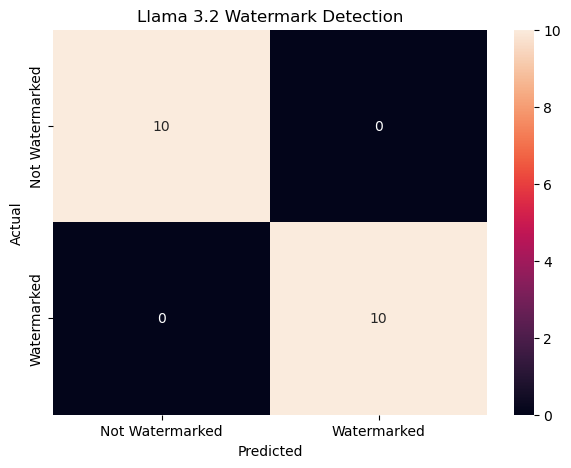

In [23]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Watermarked", "Watermarked"],
    yticklabels=["Not Watermarked", "Watermarked"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Llama 3.2 Watermark Detection")
plt.show()


## 23. Final inference function

In [24]:
def final_detector(text):
    tfidf_features = tfidf_vectorizer.transform([text])

    wm_features = np.array([
        extract_watermark_features(text)
    ])

    style = np.array([
        stylometric_features(text)
    ])

    extra = csr_matrix(
        np.hstack([wm_features, style])
    )

    baseline_features = hstack([
        tfidf_features,
        extra
    ])

    if USE_SENTENCE_EMBEDDINGS:
        text_embedding = embedding_model.encode(
            [text],
            convert_to_numpy=True,
            normalize_embeddings=True
        )
        final_features = hstack([
            baseline_features,
            csr_matrix(text_embedding)
        ])
    else:
        final_features = baseline_features

    probability = classifier.predict_proba(
        final_features
    )[0, 1]

    wm_score = calculate_watermark_score(text)

    prediction = (
        "Watermarked"
        if probability >= 0.5
        else "Not Watermarked"
    )

    return {
        "prediction": prediction,
        "probability": float(probability),
        "z_score": float(wm_score["z_score"]),
        "green_ratio": float(wm_score["green_ratio"]),
        "total_words": int(wm_score["total_words"])
    }


## 24. Test detector

In [25]:
result = final_detector(generated_text)

for key, value in result.items():
    print(f"{key}: {value}")


prediction: Watermarked
probability: 1.0
z_score: 1.1547005383792515
green_ratio: 0.5555555555555556
total_words: 108


## 25. Generate new Llama 3.2 text and detect it

In [26]:
new_prompt = """
Explain how artificial intelligence is changing education.
"""

new_text = generate_llama_text(
    new_prompt,
    max_tokens=150
)

print("Llama 3.2 output:")
print("-" * 70)
print(new_text)

print("\nDetection:")
print("-" * 70)

result = final_detector(new_text)

for key, value in result.items():
    print(f"{key}: {value}")


Llama 3.2 output:
----------------------------------------------------------------------
Artificial intelligence (AI) is transforming the education sector in various ways, improving the learning experience, and enhancing student outcomes. Here are some key ways AI is changing education:

1. **Personalized Learning**: AI-powered adaptive learning systems can analyze student performance, learning style, and pace to provide personalized learning experiences. This approach helps students learn at their own pace, and teachers can focus on supporting students who need extra help.
2. **Intelligent Tutoring Systems**: AI-based intelligent tutoring systems can offer one-on-one support to students, providing real-time feedback, guidance, and encouragement. These systems can help students overcome learning barriers and improve their academic performance.
3. **Automated Grading**: AI-powered grading systems can reduce the time spent by

Detection:
--------------------------------------------------

## 26. Save the trained NLP model

In [27]:
joblib.dump(
    classifier,
    "llama32_nlp_watermark_classifier.pkl"
)

joblib.dump(
    tfidf_vectorizer,
    "llama32_tfidf_vectorizer.pkl"
)

print("Models saved successfully.")


Models saved successfully.


# Final Project Architecture

JSONL → preprocessing → **Ollama Llama 3.2** → normal/watermark-oriented generation → **NLP features (TF-IDF + n-grams + stylometry + watermark statistics + Sentence-Transformer embeddings)** → Logistic Regression → Watermarked / Not Watermarked → Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix.

A baseline-vs-embeddings comparison (Section 20B) shows whether the added sentence embeddings improve detection over TF-IDF + watermark stats + stylometry alone on this experimental dataset.

**No Hugging Face model hub inference endpoints. No Streamlit.** (`sentence-transformers` downloads a small local embedding model — no external API calls are made at inference time.)

For a research-grade version, use ground-truth watermark labels and evaluate on human text, unwatermarked LLM text, genuinely watermarked LLM text, and paraphrased/adversarial text.
